In [1]:
import os,sys
print(os.getcwd())
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
print("Project root directory:", project_root)
sys.path.append(project_root)

/home/zhaolei/meal-rec-ai/preprocess
Project root directory: /home/zhaolei/meal-rec-ai


In [2]:
from utils.data import concat_data_across_years,merge_with_or,root_path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
def visualization(df_main,health_tags):
    # 假设我们已经有一个DataFrame df_main，其中包含年龄组和健康标签信息
    # 创建一个新的DataFrame来存储每个健康标签在年龄组中的计数
    df_main_filtered = df_main[df_main['age_group']> 2]
    age_group_mapping = {
        3: '21-30',
        4: '31-40',
        5: '41-50',
        6: '51-60',
        7: '61-100'
    }
    df_main_filtered['age_group'] = df_main_filtered['age_group'].map(age_group_mapping)
    # 计算每个健康标签在每个年龄组中的出现次数
    health_tag_counts = df_main_filtered.groupby('age_group')[health_tags].sum().reset_index()

    # 将数据转换为透视表格式，以年龄组为行，健康标签为列
    heatmap_data = health_tag_counts.set_index('age_group')[health_tags]

    # 筛选掉在所有年龄组中计数都为零的健康标签
    non_zero_tags = heatmap_data.columns[(heatmap_data != 0).any()].tolist()
    heatmap_data_filtered = heatmap_data[non_zero_tags]

    # 创建热力图
    plt.figure(figsize=(15, 8))
    sns.heatmap(heatmap_data_filtered, annot=True, cmap='viridis', fmt='d', cbar_kws={'label': 'Count'})

    # 设置图表的标题和轴标签
    plt.title('Heatmap of Health Tags by Age Group', fontsize=16)
    plt.xlabel('Health Tags', fontsize=12)
    plt.ylabel('Age Group', fontsize=12)

    # 旋转x轴标签以便更好地显示
    plt.xticks(rotation=45, ha='right')

    # 显示图表
    plt.tight_layout()
    plt.show()
column_tag = [
    'low_calorie', 'high_calorie', 'low_carb', 'low_protein', 'high_protein', 'low_saturated_fat', 'low_sugar',
    'low_cholesterol', 'high_fiber',
    'low_sodium', 'high_potassium', 'high_iron', 'high_calcium', 'high_vitamin_d', 'high_vitamin_c', 'low_phosphorus',
    'high_folate_acid', 'high_vitamin_b12'
]
health_tag = [
    'under_weight', 'over_weight', 'blood_pressure', 'low_density_lipoprotein', 'blood_urea_nitrogen', 'opioid_misuse',
    'diabetes', 'anemia','osteoporosis'
]

# User Tagging


## 1. Demographic Info

- Gender: Male: 1, Female:2， Missing:.
- Age: >=85 years of AGE： 85

In [3]:
def demo():
    years = ['0304', '0506', '0708', '0910', '1112', '1314', '1516', '1718', '1720']
    year_char = 'C'
    type_demo = 'demographic'
    df_demo = concat_data_across_years(type_demo, 'DEMO', years, year_char)

    # Select the wanted columns. Make changes here if needed in the future.
    df_demo = df_demo[['SEQN', 'RIAGENDR', 'RIDAGEYR', 'years']]
    df_demo = df_demo.fillna(0)
    df_demo = df_demo.rename(columns={'RIAGENDR': 'gender', 'RIDAGEYR': 'age'})
    df_demo[['SEQN', 'gender', 'age']] = df_demo[['SEQN','gender', 'age']].astype(int)
    df_demo['SEQN'] = df_demo['SEQN'].astype(str)
    df_demo = df_demo.set_index('SEQN')

    # Transform ages to age groups
    bins = [-1, 10, 20, 30, 40, 50, 60, 100]
    labels = [1, 2, 3, 4, 5, 6, 7]

    # Create a new column for age groups
    df_demo['age_group'] = pd.cut(df_demo['age'], bins=bins, labels=labels, right=True).astype(int)
    return df_demo

In [4]:
df_demo=demo()
df_demo[column_tag] =0
df_demo[health_tag] =0

In [5]:
df_demo.columns

Index(['gender', 'age', 'years', 'age_group', 'low_calorie', 'high_calorie',
       'low_carb', 'low_protein', 'high_protein', 'low_saturated_fat',
       'low_sugar', 'low_cholesterol', 'high_fiber', 'low_sodium',
       'high_potassium', 'high_iron', 'high_calcium', 'high_vitamin_d',
       'high_vitamin_c', 'low_phosphorus', 'high_folate_acid',
       'high_vitamin_b12', 'under_weight', 'over_weight', 'blood_pressure',
       'low_density_lipoprotein', 'blood_urea_nitrogen', 'opioid_misuse',
       'diabetes', 'anemia', 'osteoporosis'],
      dtype='object')

## 2. Special Diet

In [6]:
def dietary():
    years = ['0304', '0506', '0708', '0910', '1112', '1314', '1516', '1718', '1720']
    year_char = 'C'
    type_dietary = 'dietary'
    df_TOT1 = concat_data_across_years(type_dietary, 'DR1TOT', years, year_char)
    columns_diet = ["DRQSDT1", "DRQSDT2", "DRQSDT3", "DRQSDT4", "DRQSDT7", "DRQSDT8", "DRQSDT9", "DRQSDT10", "DRQSDT12"]
    mappings_diet = {
        "DRQSDT1": "Weight loss/Low calorie diet", "DRQSDT2": "Low fat/Low cholesterol diet",
        "DRQSDT3": "Low salt/Low sodium diet", "DRQSDT4": "Sugar free/Low sugar diet", "DRQSDT7": "Diabetic diet",
        "DRQSDT8": "Weight gain/Muscle building diet", "DRQSDT9": "Low carbohydrate diet",
        "DRQSDT10": "High protein diet",
        "DRQSDT12": "Renal/Kidney diet"
    }

    df_diet = df_TOT1[["SEQN"] + columns_diet]
    df_diet = df_diet.fillna(0)
    df_diet.rename(columns=mappings_diet, inplace=True)
    df_diet = df_diet.astype(int)
    df_diet['SEQN'] = df_diet['SEQN'].astype(str)
    df_diet = df_diet.set_index('SEQN')
    # Convert all integers to 1s if a user is taking a diet
    df_diet = (df_diet != 0).astype(int)

    # Keep the records if there is at least one diet
    df_diet = df_diet.loc[~(df_diet == 0).all(axis=1)]

    # Some users are taking multiple diets. We need to carefully combine them when using.
    df_diet.sum(axis=1).value_counts()

    columns_diet = df_diet.columns.tolist()
    # Convert the diets to health tags
    df_diet['low_calorie'] = df_diet['Weight loss/Low calorie diet']
    df_diet['low_saturated_fat'] = df_diet['Low fat/Low cholesterol diet']
    df_diet['low_sodium'] = df_diet['Low salt/Low sodium diet']
    df_diet['low_sugar'] = df_diet['Sugar free/Low sugar diet']
    df_diet['low_sugar'] = df_diet['Diabetic diet'] | df_diet['low_sugar']
    df_diet['high_fiber'] = df_diet['Diabetic diet']
    df_diet['low_carb'] = df_diet['Low carbohydrate diet']
    df_diet['high_protein'] = df_diet['High protein diet']
    df_diet['low_protein'] = df_diet['Renal/Kidney diet']
    df_diet['low_sodium'] = df_diet['Renal/Kidney diet'] | df_diet['low_sodium']
    df_diet['low_phosphorus'] = df_diet['Renal/Kidney diet']
    df_diet['high_calorie'] = df_diet['Weight gain/Muscle building diet']
    df_diet['high_protein'] = df_diet['Weight gain/Muscle building diet'] | df_diet['high_protein']
    
    df_diet.drop(columns_diet, axis=1, inplace=True)
    
    # Combine the health tags for each user
    df_diet = df_diet.groupby('SEQN').max()
    return df_diet

In [7]:
df_diet=dietary()

In [8]:
df_diet

,low_calorie,low_saturated_fat,low_sodium,low_sugar,high_fiber,low_carb,high_protein,low_protein,low_phosphorus,high_calorie
SEQN,,,,,,,,,,
100025,0,0,1,1,1,0,0,0,0,0
100037,0,1,0,0,0,0,0,0,0,0
100042,1,0,0,0,0,0,0,0,0,0
100065,0,0,0,0,0,0,1,0,0,1
100067,0,0,0,1,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
99947,1,0,0,0,0,0,0,0,0,0
99954,0,1,0,1,1,0,0,0,0,0
99992,1,0,0,0,0,0,0,0,0,0


In [9]:
df_main = merge_with_or(df_demo, df_diet)

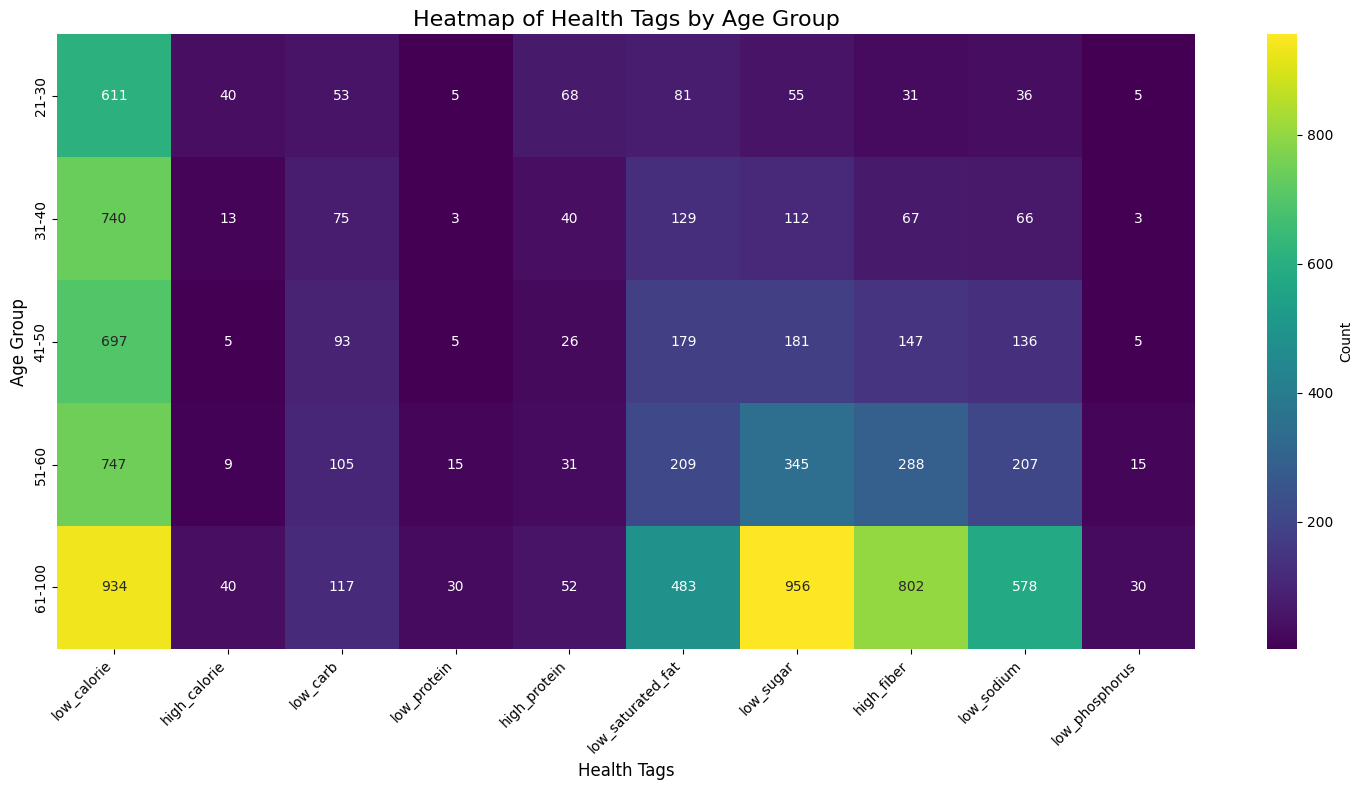

In [10]:
visualization(df_main,column_tag)

## 3. Medical Info

In [11]:
from utils.medical_condition_cal import MedicalConditions
judge=MedicalConditions()

### 3.1. Over/Under Weight

In [12]:
def Weight(df_main):
    # ### 3.1. Weight
    def tag_weight(row):
        columns=judge.judge_weight(row['BMXBMI'], row['BMXWAIST'] ,row['gender'])
        return columns['high_calorie'], columns['low_calorie'], columns['under_weight'], columns['over_weight']

    years = ['0304', '0506', '0708', '0910', '1112', '1314', '1516', '1718', '1720']
    year_char = 'C'
    type_table = 'examination'
    df_BMI = concat_data_across_years(type_table, 'BMX', years, year_char)
    df_BMI['SEQN'] = df_BMI['SEQN'].astype(int).astype(str)
    df_BMI = df_BMI[['SEQN', 'BMXBMI', 'BMXWAIST','BMXWT','BMXHT']].copy()
    df_BMI = df_BMI.merge(df_main, on='SEQN', how='left')
    df_BMI[['high_calorie', 'low_calorie', 'under_weight', 'over_weight']] = df_BMI.apply(
        lambda row: tag_weight(row), axis=1, result_type='expand')
    df_BMI = df_BMI.rename(columns={'BMXWT': 'weight'})
    df_BMI = df_BMI.rename(columns={'BMXHT': 'height'})
    df_BMI.set_index('SEQN', inplace=True)
    df_main = merge_with_or(df_main, df_BMI[['weight','height','high_calorie', 'low_calorie', 'under_weight', 'over_weight']])
    df_main = df_main.dropna(subset=['weight', 'height'])
    return df_main

In [13]:
df_main=Weight(df_main)

### 3.2. Blood Pressure

In [14]:
def Hypertension(df_main):
    years = ['0304', '0506', '0708', '0910', '1112', '1314', '1516', '1718', '1720']
    year_char = 'C'
    type_table = 'examination'

    # ### 3.2. Hypertension
    def tag_blood_pressure(row):
        columns=judge.judge_hypertension(row['Average_Systolic'] ,row['Average_Diastolic'] )
        return columns

    years = ['0304', '0506', '0708', '0910', '1112', '1314', '1516', '1718']
    year_char = 'C'
    df_BP = concat_data_across_years(type_table, 'BPX', years, year_char)
    df_BP['Average_Systolic'] = df_BP[['BPXSY1', 'BPXSY2', 'BPXSY3', 'BPXSY4']].mean(axis=1, skipna=True)
    df_BP['Average_Diastolic'] = df_BP[['BPXDI1', 'BPXDI2', 'BPXDI3', 'BPXDI4']].mean(axis=1, skipna=True)

    df_BP_O = concat_data_across_years(type_table, 'BPXO', ['1720'], year_char)
    df_BP_O['Average_Systolic'] = df_BP_O[['BPXOSY1', 'BPXOSY2', 'BPXOSY3']].mean(axis=1, skipna=True)
    df_BP_O['Average_Diastolic'] = df_BP_O[['BPXODI1', 'BPXODI2', 'BPXODI3']].mean(axis=1, skipna=True)

    df_BP_concat = pd.concat([df_BP[['SEQN', 'Average_Systolic', 'Average_Diastolic']],
                              df_BP_O[['SEQN', 'Average_Systolic', 'Average_Diastolic']]])
    df_BP_concat['SEQN'] = df_BP_concat['SEQN'].astype(int).astype(str)

    df_BP_concat[['low_sodium', 'high_potassium', 'blood_pressure']] = df_BP_concat.apply(tag_blood_pressure, axis=1,
                                                                                          result_type='expand')
    df_BP_concat.set_index('SEQN', inplace=True)

    df_main = merge_with_or(df_main, df_BP_concat[['low_sodium', 'high_potassium', 'blood_pressure']])
    return df_main

In [15]:
df_main=Hypertension(df_main)

### 3.3. Low-Density Lipoprotein

In [16]:
def High_Low_Density_Lipoprotein(df_main):
    # ### 3.3. Low-Density Lipoprotein

    type_table = 'laboratory'
    year_char = 'D'
    years = ['0506', '0708', '0910', '1112', '1314', '1516']
    df_LDL = concat_data_across_years(type_table, 'TRIGLY', years, year_char)

    years = ['1718', '1720']
    year_char = 'J'
    type_table = 'laboratory'
    df_LDL_2 = concat_data_across_years(type_table, 'TRIGLY', years, year_char)

    df_LDL_3 = concat_data_across_years(type_table, 'L13AM', ['0304'], 'C')

    df_LDL = pd.concat([df_LDL[['SEQN', 'LBDLDLSI']], df_LDL_2[['SEQN', 'LBDLDLSI']], df_LDL_3[['SEQN', 'LBDLDLSI']]])
    df_LDL['SEQN'] = df_LDL['SEQN'].astype(int).astype(str)

    def tag_LDL(row):
        #low_density_lipoprotein=1, high, 0 normal
        return judge.judge_high_low_density_lipoprotein(row['LBDLDLSI'])

    df_LDL[['low_cholesterol', 'high_fiber', 'low_saturated_fat', 'low_density_lipoprotein']] = df_LDL.apply(tag_LDL,
                                                                                                             axis=1,
                                                                                                             result_type='expand')
    df_LDL.set_index('SEQN', inplace=True)
    df_main = merge_with_or(df_main,
                            df_LDL[['low_cholesterol', 'high_fiber', 'low_saturated_fat', 'low_density_lipoprotein']])
    return df_main

In [17]:
df_main=High_Low_Density_Lipoprotein(df_main)

### 3.4. Blood Urea Nitrogen

In [18]:
def High_Blood_Urea_Nitrogen(df_main):
    # ### 3.4. Blood Urea Nitrogen
    type_table = 'laboratory'
    year_char = 'D'
    years = ['0506', '0708', '0910', '1112', '1314', '1516']
    df_SBP = concat_data_across_years(type_table, 'BIOPRO',
                                      ['0506', '0708', '0910', '1112', '1314', '1516', '1718', '1720'], 'D')
    df_temp = concat_data_across_years(type_table, 'L40',
                                       ['0304'], 'C')
    df_SBP = pd.concat([df_SBP, df_temp])[['SEQN', 'LBDSBUSI']]
    df_SBP['SEQN'] = df_SBP['SEQN'].astype(int).astype(str)

    def tag_protein(row):
        #blood_urea_nitrogen = 1 high, 0 normal
        return judge.judge_high_blood_urea_nitrogen(row['LBDSBUSI'] )

    df_SBP[['low_protein', 'blood_urea_nitrogen']] = df_SBP.apply(tag_protein, axis=1, result_type='expand')
    df_SBP.set_index('SEQN', inplace=True)
    df_main = merge_with_or(df_main, df_SBP[['low_protein', 'blood_urea_nitrogen']])
    return df_main

In [19]:
df_main=High_Blood_Urea_Nitrogen(df_main)

### 3.5. Opioid Misuse

In [20]:
def Opioid_Misuse(df_main):
    # ### 3.5. Opioid Misuse
    type_questionnaire = 'questionnaire'
    # No specific illicit drug info in 03-04 data. No such table in 17-20 data.
    df_DU = concat_data_across_years(type_questionnaire, 'DUQ',
                                     ['0506', '0708', '0910', '1112', '1314', '1516', '1718'], 'D')
    df_DU = df_DU.loc[df_DU['DUQ290'] == 1]
    df_DU = df_DU[['SEQN', 'DUQ270U', 'DUQ350U', 'DUQ300', 'DUQ310Q', 'DUQ310U']]
    df_DU = df_DU.fillna(-1)
    df_DU = df_DU.astype(int)
    """
    # We only care about those who have used heroin at least once.
    # If within a year, the user has been using any illicit drugs (heroin, meth, cocaine),
    # we identify the user as an active user.
    # Otherwise, we consider this user a recovered user.
    
    # To be specific, -1 means missing, 4 means it has been years that a user haven't used a drug.
    # If there is a value that is neither -1, nor 4 in any of the three columns, the user is an active user.
    
    # We label the active user as 1 and recovered user as 2.
    # And the rest of the users who hasn't even used heroin or other opioid prescription drugs as 0: non-opioid-user
    """
    df_DU['active_user'] = np.where(judge.judge_opioid_misuse_active_user(df_DU['DUQ270U'],
                                                                             df_DU['DUQ350U'],
                                                                             df_DU['DUQ310U']), 1, 0)
    df_DU = df_DU.rename(columns={'DUQ300': 'age_first_use_heroin', 'DUQ310U': 'last_time_unit_used_heroin',
                                  'DUQ310Q': 'last_time_used_heroin', 'DUQ270U': 'last_time_unit_used_cocaine',
                                  'DUQ350U': 'last_time_unit_used_meth'})
    df_DU['SEQN'] = df_DU['SEQN'].astype(str)
    df_DU = df_DU.set_index('SEQN')
    active_user_df = df_DU[df_DU['active_user']==1]
    active_user_set=set(active_user_df.index.tolist())
    years = ['0304', '0506', '0708', '0910', '1112', '1314', '1516', '1718', '1720']
    year_char = 'C'
    df_PM = concat_data_across_years(type_questionnaire, 'RXQ_RX', years, year_char)
    
    

    drugs = pd.read_sas(f'{root_path}RXQ_DRUG.xpt', encoding='ISO-8859-1')
    mask = drugs.apply(lambda row: judge.judge_opioid_misuse_multum_drug_therapeutic_category(row['RXDDCI1A'], row['RXDDCI1B'], row['RXDDCI1C']), axis=1)
    drug = drugs[mask]
    drug_id = set(drug['RXDDRGID'].tolist())
    mask = df_PM.apply(lambda row: judge.judge_opioid_misuse_drug_used(row['RXDUSE'], row['RXDDRGID'],drug_id, row['RXDRSC1'],row['RXDDAYS']), axis=1)
    df_PM = df_PM[mask]
    df_PM = df_PM.drop_duplicates()
    df_PM = df_PM[['SEQN', 'RXDDRUG', 'RXDDRGID', 'RXDDAYS']]
    df_PM[['SEQN', 'RXDDAYS']] = df_PM[['SEQN', 'RXDDAYS']].astype(int)
    df_PM['SEQN'] = df_PM['SEQN'].astype(str)

    """
    # We define the long term opioid users as those how have taken opioid prescriptions over 90 days.
    
    # Note that each user can take multiple opioid prescriptions.
    
    # In an earlier study for tracking long term opioid users,
    # The author excluded medications containing buprenorphine since they are used to treat use disorder.
    # However, we find multiple cases that this medicine used to treat opioid dependence.
    # So technically this also implies the user is a long term opioid user.
    """
    df_PM = df_PM.rename(columns={'RXDDRUG': 'drug_name', 'RXDDRGID': 'drug_id', 'RXDDAYS': 'days_using'})
    df_PM = df_PM.set_index('SEQN')

    # Create labels for opioid users
    opioid_user_set = set(df_PM.index.tolist())
    
    # Following the labeling scheme, we get the label in the opioid table. 0: user, 1: active user, 2: recovered_user
    df_opioid = df_demo.copy()
    df_opioid['opioid_misuse'] = 0
    def tag_opioid_misuse(row):
        return judge.judge_opioid_misuse(active_user_set,opioid_user_set, row.name)
        
    df_opioid[['low_sugar', 'high_protein', 'high_fiber','opioid_misuse']] = df_opioid.apply(tag_opioid_misuse, axis=1, result_type='expand')
    df_opioid = df_opioid[df_opioid['opioid_misuse'] == 1]
    df_main = merge_with_or(df_main, df_opioid[['low_sugar', 'high_protein', 'high_fiber', 'opioid_misuse']])
    return df_main

In [21]:
df_main=Opioid_Misuse(df_main)

### 3.6. Diabetes

In [22]:
def Diabetes(df_main):
    # ### 3.6. Diabetes
    type_table = 'laboratory'
    df_glucose_1 = concat_data_across_years(type_table, 'BIOPRO',
                                            ['0506', '0708', '0910', '1112', '1314', '1516', '1718', '1720'], 'D')
    df_glucose_2 = concat_data_across_years(type_table, 'L40',
                                            ['0304'], 'C')
    df_glucose = pd.concat([df_glucose_1, df_glucose_2])[['SEQN', 'LBDSGLSI']]

    df_ghb_1 = concat_data_across_years(type_table, 'GHB',
                                        ['0506', '0708', '0910', '1112', '1314', '1516', '1718', '1720'], 'D')
    df_ghb_2 = concat_data_across_years(type_table, 'L10',
                                        ['0304'], 'C')
    df_ghb = pd.concat([df_ghb_1, df_ghb_2])[['SEQN', 'LBXGH']]

    df_diabete = df_glucose.merge(df_ghb, on='SEQN', how='outer')
    df_diabete['SEQN'] = df_diabete['SEQN'].astype(int).astype(str)
    df_diabete.set_index('SEQN', inplace=True)

    def tag_diabetes(row):
        return judge.judge_diabetes(row['LBDSGLSI'],row['LBXGH'])

    df_diabete[['low_sugar', 'high_fiber', 'diabetes']] = df_diabete.apply(tag_diabetes, axis=1, result_type='expand')
    df_main = merge_with_or(df_main, df_diabete[['low_sugar', 'high_fiber', 'diabetes']])
    return df_main

In [23]:
df_main =Diabetes(df_main)

### 3.7. Red Blood Cell Count & Hemoglobin

In [24]:
def Anemia(df_main):
    # ### 3.7. Red Blood Cell Count & Hemoglobin
    type_table = 'laboratory'
    df_blood_1 = concat_data_across_years(type_table, 'CBC',
                                          ['0506', '0708', '0910', '1112', '1314', '1516', '1718', '1720'], 'D')
    df_blood_2 = concat_data_across_years(type_table, 'L25',
                                          ['0304'], 'C')
    df_blood = pd.concat([df_blood_1, df_blood_2])[['SEQN', 'LBXRBCSI', 'LBXHGB']]
    df_blood['SEQN'] = df_blood['SEQN'].astype(int).astype(str)
    df_blood.set_index('SEQN', inplace=True)
    df_blood = df_blood.merge(df_demo, left_index=True, right_index=True, how='left')

    def tag_RBC(row):
        return judge.judge_anemia(row['LBXRBCSI'],row['LBXHGB'],row['gender'] )

    df_blood[['high_iron', 'high_vitamin_c', 'high_folate_acid', 'high_vitamin_b12', 'anemia']] = df_blood.apply(
        tag_RBC, axis=1, result_type='expand')
    df_main = merge_with_or(df_main,
                            df_blood[['high_iron', 'high_vitamin_c', 'high_folate_acid', 'high_vitamin_b12', 'anemia']])
    return df_main

In [25]:
df_main=Anemia(df_main)

### 3.8. Osteoporosis

In [26]:
def Osteoporosis(df_main):
    # ### 3.8. Osteoporosis
    type_table = 'questionnaire'
    # Note that we don't actually have data for 11-12 and 15-16.
    df_ost = concat_data_across_years(type_table, 'OSQ',
                                      ['0304', '0506', '0708', '0910', '1112', '1314', '1516', '1718', '1720'], 'C')
    df_ost = df_ost.drop_duplicates()
    df_ost['SEQN'] = df_ost['SEQN'].astype(int).astype(str)
    df_ost = df_ost.set_index('SEQN')
    def tag_osteoporosis(row):
        return judge.judge_osteoporosis(row['OSQ060'])
    df_ost[['high_calcium', 'high_vitamin_d', 'high_vitamin_c', 'osteoporosis']] = df_ost.apply(tag_osteoporosis, 
                                                                                                axis=1, result_type='expand')
    df_ost=df_ost[df_ost['osteoporosis']==1]
    df_main = merge_with_or(df_main, df_ost[['high_calcium', 'high_vitamin_d', 'high_vitamin_c', 'osteoporosis']])
    return df_main

In [27]:
df_main=Osteoporosis(df_main)

In [28]:
df_main = df_main.drop_duplicates()
df_main = df_main.dropna(subset=['weight', 'height'])
for column in column_tag:
        df_main = df_main.rename(columns={column: 'user_' + column})
df_main = df_main.rename_axis('user_id')
df_main = df_main[df_main['age'] >= 19]
df_main.head()

,gender,age,years,age_group,user_low_phosphorus,user_low_carb,weight,height,user_low_calorie,user_high_calorie,...,diabetes,user_high_fiber,user_high_folate_acid,user_high_vitamin_b12,user_high_iron,anemia,user_high_vitamin_d,user_high_vitamin_c,user_high_calcium,osteoporosis
user_id,,,,,,,,,,,,,,,,,,,,,
21005,1,19,0304,2,0,0,137.6,164.5,1,0,...,0,0,0,0,0,0,0,0,0,0
21009,1,55,0304,6,0,0,103.1,181.6,1,0,...,0,0,0,0,0,0,0,0,0,0
21010,2,52,0304,6,0,0,67.9,163.2,1,0,...,0,0,0,0,0,0,0,0,0,0
21012,1,63,0304,7,0,0,59.2,173.8,0,0,...,0,0,0,0,0,0,0,0,0,0
21015,1,83,0304,7,0,0,78.7,166.7,1,0,...,0,0,0,0,0,0,0,0,0,0


In [29]:
file_path = f'{root_path}users.csv'
df_main.to_csv(file_path)

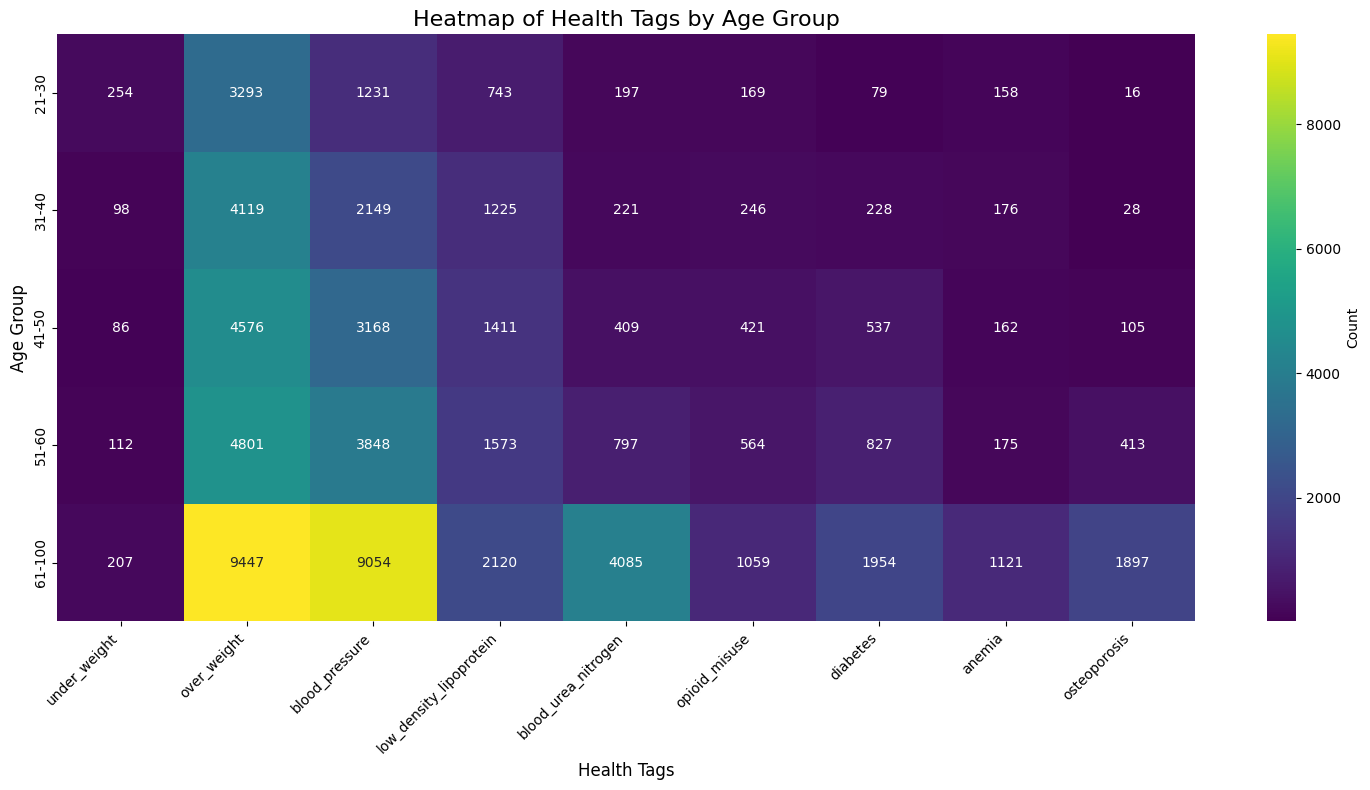

In [30]:
visualization(df_main,health_tag)